# Aplicação da Primeira Ferramenta AutoML: FLAML

**Nome da ferramenta:** FLAML (Fast and Lightweight AutoML).

**Breve descrição:** Desenvolvido pela Microsoft, o FLAML é uma biblioteca focada em encontrar modelos de Machine Learning precisos com baixo custo computacional. Ele se destaca por sua velocidade, utilizando um sistema de busca heurística que otimiza rapidamente os hiperparâmetros e seleciona os melhores algoritmos (como LightGBM, XGBoost e Random Forest) de forma eficiente.

**Como foi feita a instalação:** A biblioteca foi instalada em um ambiente virtual isolado utilizando o gerenciador de pacotes `uv` na máquina local rodando CachyOS. O comando utilizado foi `uv add flaml`.

**Nota de Atualização do Experimento:** Após a análise exploratória, a equipe aplicou *Feature Engineering* para unificar as variáveis isoladas de estresse, ansiedade e depressão em um único alvo composto (`mental_health_risk`), convertendo o problema original de regressão para uma tarefa de **Classificação Binária** (0 = Risco Baixo, 1 = Risco Alto), visando maior precisão preditiva e alinhamento com a proposta de detecção de risco do dataset.

# 0. Importação de Dependências:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from flaml import AutoML
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.utils.class_weight import compute_sample_weight

Configurações visuais para os gráficos gerados:

In [156]:
sns.set_theme(style="whitegrid")

# 1. Carregando os dados padronizados da camada Silver

In [139]:
TRAIN_PATH = '../data/silver/train.csv'
TEST_PATH = '../data/silver/test.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Tamanho do conjunto de Treino: {df_train.shape}")
print(f"Tamanho do conjunto de Teste:  {df_test.shape}")

Tamanho do conjunto de Treino: (1870, 12)
Tamanho do conjunto de Teste:  (240, 12)


Separando as features (X) e a variável-alvo (y)

In [140]:
target_col = 'depression_label'

# Separando features (X) e alvo (y)
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f"Treino (Balanceado via SMOTE): Features {X_train.shape}, Target {y_train.shape}")
print(f"Proporção da Classe 1 no Treino: {y_train.mean() * 100:.2f}%\n")

print(f"Teste (Mundo Real / Desbalanceado): Features {X_test.shape}, Target {y_test.shape}")
print(f"Proporção da Classe 1 no Teste: {y_test.mean() * 100:.2f}%")

Treino (Balanceado via SMOTE): Features (1870, 11), Target (1870,)
Proporção da Classe 1 no Treino: 50.00%

Teste (Mundo Real / Desbalanceado): Features (240, 11), Target (240,)
Proporção da Classe 1 no Teste: 2.50%


# 2. Configuração e Treinamento do FLAML

In [141]:
automl = AutoML()

# Configurações do experimento
time = 60 * 5
log_path = '../logs/flaml/'
log_filename = f'time-60x{time // 60}.log'

Isso avisa o modelo que a classe 1 (mesmo com SMOTE) é "mais pesada" em importância:

In [142]:
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

### A) Usando Holdout:

In [ ]:
# method = 'holdout'
# A_log_file = f'{method}_{log_filename}'

# A_automl_settings = {
#     "time_budget": time,            # Tempo máximo em segundos (60s é suficiente para 1200 registros)
#     "metric": metric,               # Métrica principal a ser otimizada
#     "task": 'regression',         # Tipo de problema
#     "log_file_name": log_path + A_log_file, # Arquivo para salvar os logs de execução
#     "seed": 42,                   # Semente para reprodutibilidade
#     "verbose": 2                  # Nível de detalhes impressos no console
# }

### B) Usando Cross-Validation

In [ ]:
# method = 'cv-5'
# B_log_file = f'{method}_{log_filename}'

# B_automl_settings = {
#     "time_budget": time,           # Aumentamos para 120s, pois o K-Fold exige treinar K vezes mais modelos
#     "metric": metric,               # Métrica de otimização
#     "task": 'regression',         # Tipo de problema
    
#     # --- CONFIGURAÇÕES DE CROSS-VALIDATION ---
#     "eval_method": "cv",          # Força o FLAML a usar Cross-Validation em vez de Holdout
#     "split_type": KFold(n_splits=3, shuffle=True, random_state=42), # Divide o treino em 5 partes
    
#     "log_file_name": log_path + B_log_file, 
#     "seed": 42,                   
#     "verbose": 2                  
# }

### C) Usando validação Estratificada:

In [143]:
tree_models = ['rf']
metric = 'f1'
C_log_file = f'bin-class-smote-trees_metric-{metric}_{log_filename}'

C_automl_settings = {
    "time_budget": time,           
    "metric": metric,          
    "task": 'classification',
    "eval_method": "cv",          
    "split_type": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "log_file_name": log_path + C_log_file, 
    "seed": 42,                   
    "verbose": 2,
    "estimator_list": tree_models                  
}

### D) Usando Regressão com MAE

In [ ]:
# metric = 'mae'
# D_log_file = f'reg_metric-{metric}_{log_filename}'

# D_automl_settings = {
#     "time_budget": time,           
#     "metric": metric,              # Mudamos para MAE: minimiza o erro absoluto na escala de 0-100
#     "task": 'regression',         
#     "eval_method": "cv",          
#     "split_type": KFold(n_splits=5, shuffle=True, random_state=42),
#     "log_file_name": log_path + D_log_file,
#     "seed": 42,
#     "verbose": 2
# }

## 2.1. Executando a etapa de treinamento do FlaML:

In [144]:
print("Iniciando o treinamento do FLAML (Pesos Balanceados e Foco em F1)...")
automl.fit(X_train=X_train, y_train=y_train, sample_weight=sample_weight, **C_automl_settings)
print("Treinamento Finalizado!")

Iniciando o treinamento do FLAML (Pesos Balanceados e Foco em F1)...
Treinamento Finalizado!


# 3. Extração de Resultados do Treinamento:

## 3.1. Modelos testados e Melhor Modelo Encontrado:

In [ ]:
print("=== Resultados do FLAML ===")

print("\nModelos (Estimators) avaliados:")
print(list(automl.best_config_per_estimator.keys()))

print(f"\nMelhor modelo encontrado: {automl.best_estimator}")

print("\nHiperparâmetros otimizados:")
print(automl.best_config)

print(f"\nTempo de busca (Search Time): {automl.best_config_train_time:.2f} segundos")

=== Resultados do FLAML ===

Modelos (Estimators) avaliados:
['rf']

Melhor modelo encontrado: rf

Hiperparâmetros otimizados:
{'n_estimators': 266, 'max_features': np.float64(0.17482732420788064), 'max_leaves': 934, 'criterion': np.str_('entropy')}

Tempo de busca (Search Time): 0.31 segundos


## 3.2. Avaliação com dados invisíveis e DESBALANCEADOS (Test Set)

In [ ]:
# É aqui que provamos se o SMOTE funcionou sem causar overfitting
y_pred_proba = automl.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 3. Calcular o F1-Score para cada limiar testado
# (Adicionamos um aviso de supressão para divisões por zero temporárias)
np.seterr(divide='ignore', invalid='ignore')
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores) # Substitui NaNs por 0

# 4. Localizar o limiar que gerou o MAIOR F1-Score
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print(f"Limiar padrão do sistema: 0.5000")
print(f"Novo Limiar Otimizado: {best_threshold:.4f}")
print(f"F1-Score Máximo Alcançável (Classe 1): {best_f1:.4f}\n")

# 5. Aplicar o novo limiar customizado
# Se a probabilidade for maior ou igual ao novo limiar, vira 1. Senão, 0.
y_pred_custom = (y_pred_proba >= best_threshold).astype(int)

print("=== Novo Relatório de Classificação (Com Limiar Ajustado) ===")
print(classification_report(y_test, y_pred_custom))

Limiar padrão do sistema: 0.5000
Novo Limiar Otimizado: 0.1767
F1-Score Máximo Alcançável (Classe 1): 0.2791

=== Novo Relatório de Classificação (Com Limiar Ajustado) ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93       234
           1       0.16      1.00      0.28         6

    accuracy                           0.87       240
   macro avg       0.58      0.93      0.60       240
weighted avg       0.98      0.87      0.91       240



## 3.3. Matriz de Confusão:

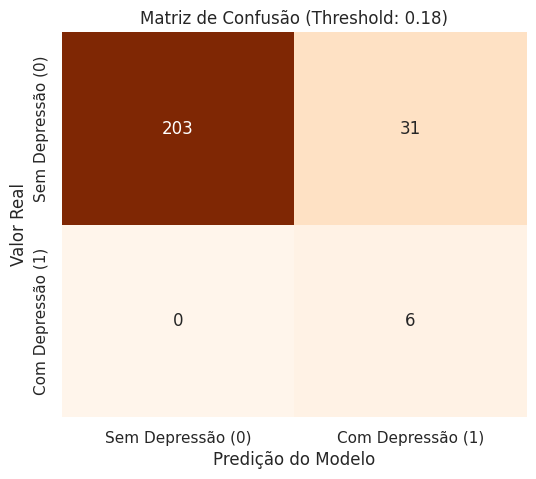

In [158]:
cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Sem Depressão (0)', 'Com Depressão (1)'],
            yticklabels=['Sem Depressão (0)', 'Com Depressão (1)'])
plt.title(f'Matriz de Confusão (Threshold: {best_threshold:.2f})')
plt.ylabel('Valor Real')
plt.xlabel('Predição do Modelo')
plt.show()

## 3.4. Gráfico de Decisão de Limear:

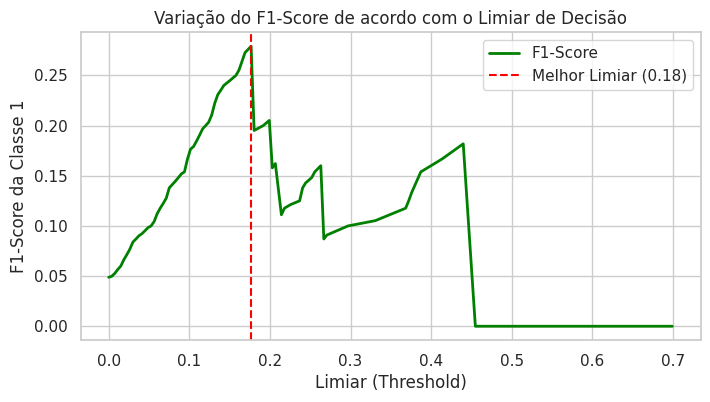

In [163]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.title('Variação do F1-Score de acordo com o Limiar de Decisão')
plt.xlabel('Limiar (Threshold)')
plt.ylabel('F1-Score da Classe 1')
plt.legend()
plt.show()

# 4. Recursos gerados pela ferramenta (Gráficos / Importância de atributos):

In [161]:
best_model = automl.model.estimator
feature_names = X_train.columns

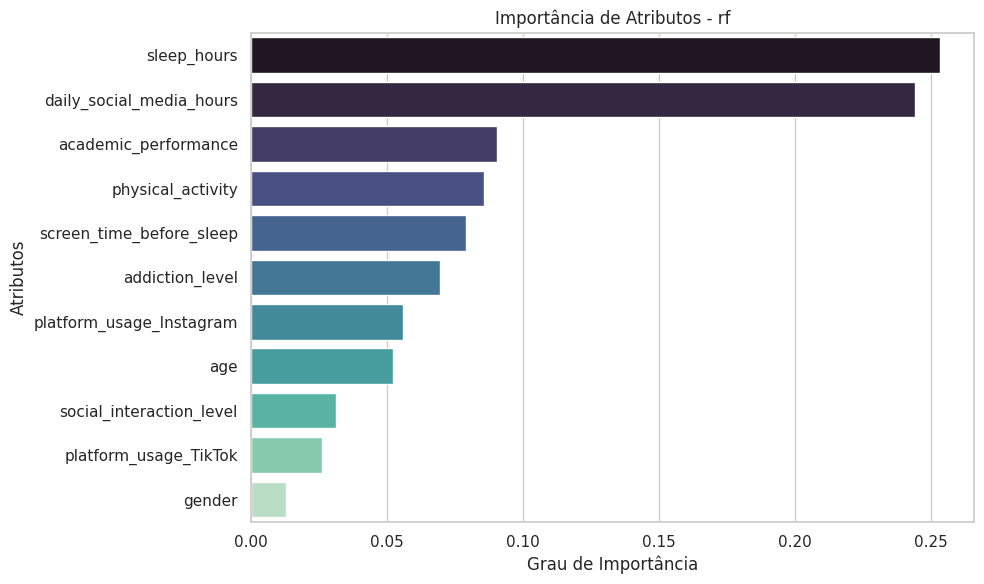

                     Feature  Importance
3                sleep_hours    0.253220
2   daily_social_media_hours    0.244012
5       academic_performance    0.090561
6          physical_activity    0.085740
4   screen_time_before_sleep    0.079118
8            addiction_level    0.069546
9   platform_usage_Instagram    0.055678
0                        age    0.052018
7   social_interaction_level    0.031338
10     platform_usage_TikTok    0.026131
1                     gender    0.012637


In [162]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    
    df_importances = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_importances, x='Importance', y='Feature', palette='mako', hue="Feature")
    plt.title(f"Importância de Atributos - {automl.best_estimator}")
    plt.xlabel("Grau de Importância")
    plt.ylabel("Atributos")
    plt.tight_layout()
    plt.show()
    print(df_importances)
else:
    print("O modelo vencedor não suporta a extração direta de 'feature_importances_'.")

### Teste 1 (5 min):
```
=== Desempenho no Conjunto de Teste ===
Métrica Principal de Competição (R²): 0.0016
Mean Absolute Error (MAE): 2.4759
Root Mean Squared Error (RMSE): 2.8690
```

### Teste 2 (5 min):
##### Resultado:
```
=== Resultados do FLAML ===

Modelos (Estimators) disponíveis e testados pela ferramenta:
['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost']

Melhor modelo encontrado (Best Estimator): extra_tree

Hiperparâmetros otimizados do melhor modelo:
{'n_estimators': 7, 'max_features': np.float64(0.688004434056633), 'max_leaves': 4}

Tempo aproximado de execução (Search Time): 0.01 segundos
```
##### Desempenho:
```
=== Desempenho no Conjunto de Teste ===
Métrica Principal de Competição (R²): 0.0016
Mean Absolute Error (MAE): 2.4759
Root Mean Squared Error (RMSE): 2.8690
```

# Resultados:

### Resultados do FLAML:

```
Modelos (Estimators) avaliados: ['rf']
Melhor modelo encontrado: rf
Hiperparâmetros otimizados: {'n_estimators': 266, 'max_features': np.float64(0.17482732420788064), 'max_leaves': 934, 'criterion': np.str_('entropy')}
Tempo de busca (Search Time): 0.31 segundos
```

#### F1-Score:
```
Limiar padrão do sistema: 0.5000
Novo Limiar Otimizado: 0.1767
F1-Score Máximo Alcançável (Classe 1): 0.2791

=== Novo Relatório de Classificação (Com Limiar Ajustado) ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93       234
           1       0.16      1.00      0.28         6

    accuracy                           0.87       240
   macro avg       0.58      0.93      0.60       240
weighted avg       0.98      0.87      0.91       240
```

#### Importância de Atributos - RF
```
                     Feature  Importance
3                sleep_hours    0.253220
2   daily_social_media_hours    0.244012
5       academic_performance    0.090561
6          physical_activity    0.085740
4   screen_time_before_sleep    0.079118
8            addiction_level    0.069546
9   platform_usage_Instagram    0.055678
0                        age    0.052018
7   social_interaction_level    0.031338
10     platform_usage_TikTok    0.026131
1                     gender    0.012637
```